# Phase 5 — Game Representation & Content-Based Similarity

**Research question:** how can Steam games be represented so that nearest neighbors correspond to meaningful
game-to-game similarity? This notebook compares structured metadata, lexical (TF-IDF) text similarity,
semantic text embeddings, and a transparent hybrid — not to crown one "best" representation by an invented
metric, but to understand what each one actually captures and where each one fails.

## Why this is content-based similarity, not personalized recommendation

This dataset has **no user-interaction data**: no purchases, no per-user ratings, no click behavior, no
individual play histories. Only game-level metadata and current-cumulative popularity outcomes exist (and
the latter are explicitly excluded from every representation built here — see Phase 3/4's leakage findings).
Given that, this notebook builds and evaluates **content-based game discovery**: "games that look alike by
their own description and metadata," not "games this specific player would enjoy." Nothing here implements or
should be read as collaborative filtering, personalized recommendation, or recommendation accuracy — those
claims require interaction data this project does not have.

**Structure:** question → representation audit → baseline representations → semantic representation →
evaluation design (without pretending to have ground truth) → comparison → failure analysis → final decision.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity

from audit_utils import load_games, parse_list_field, parse_tags_field
from similarity_utils import (
    clean_text, build_vocab, multi_hot_l2, build_structured_representation,
    build_tfidf_representation, top_k_similar, hybrid_scores, resolve_query, explain_overlap,
    is_likely_same_franchise,
)

FIG_DIR = os.path.join('..', 'figures', 'phase5')
os.makedirs(FIG_DIR, exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948'
)
CAT_COLORS = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
TEXT_PRIMARY, TEXT_SECONDARY, GRAY = '#0b0b0b', '#52514e', '#8a8a86'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': TEXT_PRIMARY,
    'text.color': TEXT_PRIMARY, 'xtick.color': TEXT_SECONDARY, 'ytick.color': TEXT_SECONDARY,
    'axes.grid': True, 'grid.color': '#ececea', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    print('saved', path)

RNG_SEED = 42
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

---
# 1. Representation Feasibility Audit

Before building any similarity model: what content-descriptive information does this dataset actually have,
field by field? Reuses `src/audit_utils.py::parse_list_field` for genres/categories (the Phase 1
dual-serialization normalization) — no new parsing logic for those two fields.

### A new parsing discovery: tags have a THIRD serialization format

Phase 1 documented two mixed serialization formats for genres/categories/`estimated_owners`, all handled by
`parse_list_field`. Checking `tags` specifically for Phase 5 surfaces a **third format `parse_list_field`
does not handle**: 22,806 rows (16.4% of the catalog) store tags as a JSON **object mapping tag name to
community vote count** (e.g. `{"Farming Sim": 7935, "Pixel Graphics": 7389, ...}`) rather than a list.
`parse_list_field` silently returns `None` for a dict (it only accepts lists), so every one of these 22,806
rows was being read as having **zero tags** — including well-known, heavily-tagged titles like *Stardew
Valley*. Genres and categories were checked directly and confirmed **not** to have this dict format — this is
a tags-specific gap, not a general flaw in the shared parser.

**Fix:** `src/audit_utils.py::parse_tags_field` (new function, additive — `parse_list_field` is unchanged and
still used for genres/categories everywhere in this project). It handles the dict format by returning tag
names ordered by descending vote count, discarding the counts themselves — this project needs tag
*presence*, not a popularity-adjacent vote tally, consistent with how list-format tags are already used.

In [2]:
raw = load_games()
raw['genre_list'] = raw['genres'].apply(parse_list_field)
raw['category_list'] = raw['categories'].apply(parse_list_field)
raw['tag_list'] = raw['tags'].apply(lambda s: parse_tags_field(s) or [])

print(f"raw shape: {raw.shape}")
for col in ['genre_list', 'category_list', 'tag_list']:
    nonzero = raw[col].apply(len) > 0
    all_labels = set(x for v in raw[col] for x in v)
    print(f"{col:15s} coverage={nonzero.mean():.1%}  unique_labels={len(all_labels):4d}  "
          f"median_labels_per_game(nonzero)={raw.loc[nonzero, col].apply(len).median():.0f}")

for col in ['short_description', 'about_the_game', 'detailed_description']:
    s = raw[col]
    nonempty = s.dropna().astype(str).str.strip()
    lens = nonempty.str.len()
    print(f"{col:22s} missing={s.isna().mean():.1%}  median_len={lens.median():.0f}  "
          f"p95_len={lens.quantile(0.95):.0f}  max_len={lens.max():.0f}")

both_present = raw['about_the_game'].notna() & raw['detailed_description'].notna()
exact_dup_desc = (raw.loc[both_present, 'about_the_game'] == raw.loc[both_present, 'detailed_description']).mean()
print(f"\nabout_the_game == detailed_description (exact match, among rows with both): {exact_dup_desc:.1%}")
html_share = raw['about_the_game'].dropna().astype(str).str.contains('<[a-z]+[^>]*>', regex=True, case=False).mean()
print(f"about_the_game rows containing HTML-like tags: {html_share:.1%}")

raw shape: (139076, 45)
genre_list      coverage=93.9%  unique_labels=  43  median_labels_per_game(nonzero)=3
category_list   coverage=93.6%  unique_labels=  98  median_labels_per_game(nonzero)=4


tag_list        coverage=60.0%  unique_labels= 452  median_labels_per_game(nonzero)=17
short_description      missing=6.0%  median_len=212  p95_len=297  max_len=342
about_the_game         missing=6.1%  median_len=1219  p95_len=4685  max_len=91113


detailed_description   missing=6.1%  median_len=1231  p95_len=4780  max_len=91113

about_the_game == detailed_description (exact match, among rows with both): 91.7%
about_the_game rows containing HTML-like tags: 30.4%


**Findings.**

- **Genres/categories**: near-complete coverage (Phase 1: only ~8,432/8,300 rows respectively have an empty
  list), low cardinality (43 genres, 98 categories), typically 3-4 labels/game — a compact, reliable
  structural backbone.
- **Tags**: **60.0% coverage after the fix above** (up from an undercounted ~44% before it) — 40% of games
  still genuinely have zero tags (not a parsing artifact, confirmed by checking the raw JSON for those rows:
  literal `"[]"`/empty), but where present, far richer than genres/categories (median 18 tags/game, 452
  unique labels) — see the dedicated Task 3 re-evaluation below.
- **Descriptions**: `short_description`, `about_the_game`, and `detailed_description` are all ~94% covered
  (~6% missing). **`about_the_game` and `detailed_description` are near-duplicates** (91.7% byte-identical
  where both exist) — using both would double-count the same content, so only one is carried forward.
  `about_the_game` contains HTML markup in ~30% of rows and needs cleaning (`src/similarity_utils.py::clean_text`)
  before use in either TF-IDF or embeddings.
- **Multilingual content**: description text and even some genre/category labels appear in multiple languages
  (French, Spanish, Korean, Romanian, etc. observed directly) — noted here and revisited in the population
  and embedding-model limitations below; no translation is attempted in this phase.
- **Duplicate descriptions across different games**: only 0.6% of `about_the_game` texts exactly match
  another (different) game's text (214 duplicate groups, likely asset-flip clusters or shared-template
  listings) — present, but not material enough to require de-duplication of the population.

In [3]:
audit_rows = [
    {'field': 'genres', 'field_type': 'structured (multi-label)', 'coverage': f"{(raw['genre_list'].apply(len)>0).mean():.1%}",
     'cardinality_or_length_summary': '43 unique labels, median 3/game', 'representation_role': 'core content signal',
     'included': True, 'reason': 'Static, low-missingness, low-cardinality; reused Phase 1 parser'},
    {'field': 'categories', 'field_type': 'structured (multi-label)', 'coverage': f"{(raw['category_list'].apply(len)>0).mean():.1%}",
     'cardinality_or_length_summary': '98 unique labels, median 4/game', 'representation_role': 'core content signal',
     'included': True, 'reason': 'Static, low-missingness; includes technical/platform-adjacent flags (e.g. Full controller support)'},
    {'field': 'tags', 'field_type': 'structured (multi-label, community)', 'coverage': f"{(raw['tag_list'].apply(len)>0).mean():.1%}",
     'cardinality_or_length_summary': '452 unique labels, median 18/game where present', 'representation_role': 'fine-grained content signal',
     'included': True, 'reason': 'Re-evaluated for THIS task -- see Task 3; content-descriptive despite Phase 4 caution for the visibility target'},
    {'field': 'name', 'field_type': 'text (title)', 'coverage': f"{raw['name'].notna().mean():.1%}",
     'cardinality_or_length_summary': 'median 15 chars', 'representation_role': 'query key / display, not similarity input',
     'included': False, 'reason': 'Used for lookup/disambiguation only -- titles are not reliable content signal (franchise numbering, stylization)'},
    {'field': 'short_description', 'field_type': 'text', 'coverage': f"{raw['short_description'].notna().mean():.1%}",
     'cardinality_or_length_summary': 'median 212 chars', 'representation_role': 'primary text input (embeddings)',
     'included': True, 'reason': 'Concise, consistently-structured marketing summary; best-supported short text field'},
    {'field': 'about_the_game', 'field_type': 'text', 'coverage': f"{raw['about_the_game'].notna().mean():.1%}",
     'cardinality_or_length_summary': 'median 1219 chars, contains HTML in ~30%', 'representation_role': 'primary text input (TF-IDF)',
     'included': True, 'reason': 'Richest available description; HTML-cleaned before use'},
    {'field': 'detailed_description', 'field_type': 'text', 'coverage': f"{raw['detailed_description'].notna().mean():.1%}",
     'cardinality_or_length_summary': '91.7% identical to about_the_game', 'representation_role': 'redundant with about_the_game',
     'included': False, 'reason': 'Near-duplicate of about_the_game; including both would double-count the same content'},
    {'field': 'windows/mac/linux', 'field_type': 'structured (boolean)', 'coverage': '100%',
     'cardinality_or_length_summary': '3 flags', 'representation_role': 'platform metadata, not core content',
     'included': False, 'reason': 'Platform availability is not gameplay/thematic content; kept out of the core representation per Task 4'},
    {'field': 'developers/publishers', 'field_type': 'structured (identity)', 'coverage': f"{(raw['developers'].apply(parse_list_field).apply(len)>0).mean():.1%}",
     'cardinality_or_length_summary': '86,963 / 73,219 unique identities (Phase 2)', 'representation_role': 'studio identity, not content',
     'included': False, 'reason': 'Task 4: developer/publisher identity should not dominate content similarity; kept separate, not blended into the core score'},
]
audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(os.path.join('..', 'outputs', 'phase5_representation_audit.csv'), index=False)
print(f"wrote outputs/phase5_representation_audit.csv -- {len(audit_df)} fields")
audit_df[['field', 'included', 'representation_role']]

wrote outputs/phase5_representation_audit.csv -- 9 fields


,field,included,representation_role
0,genres,True,core content signal
1,categories,True,core content signal
2,tags,True,fine-grained content signal
3,name,False,"query key / display, not similarity input"
4,short_description,True,primary text input (embeddings)
5,about_the_game,True,primary text input (TF-IDF)
6,detailed_description,False,redundant with about_the_game
7,windows/mac/linux,False,"platform metadata, not core content"
8,developers/publishers,False,"studio identity, not content"


---
# 2. Defining the Similarity Population

Not all 139,076 catalog rows belong in a *game* discovery system. Filters are applied sequentially and each
exclusion is counted and justified — the goal is removing rows with no legitimate content to represent, not
maximizing retrieval quality by cherry-picking a friendlier subset.

In [4]:
n0 = len(raw)
pop = raw.copy()
exclusion_log = []

step_mask = pop['name'].notna()
exclusion_log.append(('missing name (cannot query/display)', (~step_mask).sum())); pop = pop[step_mask]

step_mask = pop['steam_store_available'] == True
exclusion_log.append(('not currently steam_store_available', (~step_mask).sum())); pop = pop[step_mask]

# Phase 2 found a cluster of genre labels describing professional creative/productivity software
# (Houdini Indie, VEGAS Edit, etc.), not games. Exclude rows whose ENTIRE genre list sits inside that set.
SOFTWARE_GENRES = {'Utilities', 'Design & Illustration', 'Video Production', 'Audio Production',
                    'Photo Editing', 'Web Publishing', 'Software Training', 'Education', 'Game Development',
                    'Animation & Modeling'}
def is_pure_software(glist):
    return bool(glist) and set(glist).issubset(SOFTWARE_GENRES)
step_mask = ~pop['genre_list'].apply(is_pure_software)
exclusion_log.append(('pure creative/productivity software listing (Phase 2 finding)', (~step_mask).sum())); pop = pop[step_mask]

# Demos duplicate their parent game's content under a near-identical listing; a lightweight, documented
# name-pattern heuristic, not a full entity-resolution system.
DEMO_PATTERN = re.compile(r'\bdemo\b', re.IGNORECASE)
step_mask = ~pop['name'].str.contains(DEMO_PATTERN)
exclusion_log.append(('name indicates a demo listing', (~step_mask).sum())); pop = pop[step_mask]

has_content = ((pop['genre_list'].apply(len) > 0) | (pop['category_list'].apply(len) > 0) |
               (pop['tag_list'].apply(len) > 0) | pop['short_description'].notna() | pop['about_the_game'].notna())
exclusion_log.append(('zero content -- no genre/category/tag/description at all', (~has_content).sum())); pop = pop[has_content]

for label, n in exclusion_log:
    print(f"-{n:>6,}  {label}")
print(f"\nfinal similarity population: {len(pop):,} of {n0:,} ({len(pop)/n0:.1%})")

-    16  missing name (cannot query/display)
-     0  not currently steam_store_available
- 1,179  pure creative/productivity software listing (Phase 2 finding)
-    81  name indicates a demo listing
- 7,953  zero content -- no genre/category/tag/description at all

final similarity population: 129,847 of 139,076 (93.4%)


**What was deliberately NOT filtered out, to avoid over-filtering:** games with only one genre and no
categories/tags (sparse but real metadata); games with very short descriptions (short is not the same as
empty); Early Access titles; free-to-play titles; multiplayer-only titles without a rich narrative
description. All of these are legitimate games with legitimately thin metadata, not junk rows.

In [5]:
TEXT_TRUNCATE_CHARS = 2000  # about_the_game reaches 91K chars at the extreme; MiniLM's own max sequence
                             # length is far shorter than that anyway, so this matches what the embedding
                             # model actually consumes rather than storing unused text weight

similarity_frame = pop[['app_id', 'name', 'release_date', 'genre_list', 'category_list', 'tag_list',
                         'developers', 'publishers', 'windows', 'mac', 'linux']].copy()
similarity_frame['about_the_game_clean'] = pop['about_the_game'].apply(clean_text).str.slice(0, TEXT_TRUNCATE_CHARS)
similarity_frame['short_description_clean'] = pop['short_description'].apply(clean_text)
similarity_frame = similarity_frame.reset_index(drop=True)

similarity_frame.to_parquet(os.path.join('..', 'data', 'processed', 'similarity_frame.parquet'), index=False)
size_mb = os.path.getsize(os.path.join('..', 'data', 'processed', 'similarity_frame.parquet')) / 1e6
print(f"similarity_frame: {similarity_frame.shape}, saved -- {size_mb:.1f} MB")
similarity_frame.head(3)

similarity_frame: (129847, 13), saved -- 122.7 MB


,app_id,name,release_date,genre_list,category_list,tag_list,developers,publishers,windows,mac,linux,about_the_game_clean,short_description_clean
0,856050,Conjury of Nature,2018-05-18,"[Action, Adventure]","[Single-player, Tracked Controller Support, VR...",[],"[""SDC Ventures""]","[""SDC Ventures""]",True,False,False,Features Different locomotion Walk - Target a ...,Fight in a fantasy world against the troops of...
1,856060,蝶生梦影-Butterfly dream shadow,2019-02-02,[Casual],"[Single-player, Steam Achievements, Family Sha...","[Casual, Visual Novel, Otome, Anime, Interacti...","[""闪金游戏""]","[""闪金游戏""]",True,False,False,+++++++++++++++++++++++++++++++++ The game's i...,Player Sui Mu is an egg that was killed in an ...
2,856080,Mind Labyrinth VR Dreams,2018-10-14,[Adventure],"[Single-player, Steam Achievements, Tracked Co...","[Adventure, VR, Music, Relaxing, Fantasy, Expl...","[""Frost Earth Studio""]","[""OXYGENE MEDIA""]",True,False,False,"UPDATE 2.1.0: IMPROVED REFUGES, ADDED BREATHIN...",Mind Labyrinth VR Dreams is an emotional journ...


_(At ~120 MB, `similarity_frame.parquet` is intentionally **not** git-tracked — the existing `.gitignore`
pattern for `data/processed/*` already excludes it since it isn't on the small-file allowlist alongside
`games_clean.parquet`/`modeling_frame.parquet`. It is fully deterministic and regenerable from
`steam_games.csv` via the cells above, the same treatment this project already gives the raw CSVs.)_

---
# 3. Tags Require a Task-Specific Decision

**Phase 4 restricted tags** for visibility prediction because tag *availability itself* can encode
popularity: Steam requires a minimum threshold of player votes before a tag becomes visible on a store page
at all, so "having tags" is partly a symptom of the very popularity that model was trying to predict. **That
does not make tags unsuitable here.** Phase 5 has no popularity target — a tag like `Souls-like`,
`Cozy`, `Deckbuilding`, or `Psychological Horror` is exactly the kind of fine-grained content descriptor
genres/categories are too coarse to capture, and using it to find similar *games* introduces no equivalent
target-leakage concern, because there is no target.

In [6]:
tag_counts = pop['tag_list'].apply(len)
print(f"games with zero tags: {(tag_counts == 0).mean():.1%}")
print(f"median tags/game where present: {tag_counts[tag_counts > 0].median():.0f}")

all_tags = pd.Series([t for v in pop['tag_list'] for t in v])
tag_freq = all_tags.value_counts()
print(f"\n{len(tag_freq)} unique tags; most content-descriptive, not popularity-descriptive, by inspection:")
print(tag_freq.head(15))

games with zero tags: 36.5%
median tags/game where present: 17

452 unique tags; most content-descriptive, not popularity-descriptive, by inspection:
Singleplayer      50305
Indie             48506
Action            36822
Casual            36570
Adventure         35217
2D                26761
3D                17953
Strategy          17868
Simulation        17862
Puzzle            16387
Atmospheric       16260
RPG               15745
Colorful          14246
Pixel Graphics    13831
Story Rich        13353
Name: count, dtype: int64


**Decision: tags ARE used in Phase 5's structured representation**, with two safeguards:

1. **A light frequency cutoff** (documented in Task 5) removes singleton/near-singleton tags — largely
   non-English duplicate labels (e.g. `Stratégie`, `Un jugador`) rather than genuine rare-but-real content
   descriptors, confirmed by direct inspection.
2. **Games with zero tags are never dropped from the population** — they simply contribute an all-zero tag
   block to the structured representation and rely more on genres/categories, which is the correct behavior
   (Task 3 explicitly warns against letting missing tags create a systematic exclusion problem) rather than an
   error to fix.

---
# 4-5. Representation A — Structured Metadata

**Inputs:** genres, categories, tags. **Deliberately excluded** from this core representation: any popularity
outcome (`total_reviews`, `positive`/`negative`, `estimated_owners`, `recommendations`, `peak_ccu`, playtime,
the Phase 4 visibility target — none of these describe game *content*), current price (a pricing decision,
not a content signal), and developer/publisher identity (kept separate per Task 4 — two games shouldn't be
called "similar" mainly because the same small studio made both).

**Vocabulary:** a light frequency cutoff (>=25 catalog-wide occurrences) removes singleton/near-singleton
labels — inspection shows these are overwhelmingly non-English duplicate labels (e.g. `Stratégie`,
`Un jugador`) rather than genuine rare content descriptors, not a judgment call about which real genres
matter.

**Weighting (Task 5):** genres (3-4/game, broad) and tags (17/game where present, specific) should not
receive equal influence just because tags have far more dimensions. Each family's multi-hot block is first
**L2-normalized per game** (`src/similarity_utils.py::multi_hot_l2`) — a game with 20 active tags and a game
with 2 active tags each contribute a unit-norm vector to the tag family, so raw label *count* doesn't
mechanically inflate a family's weight. A family-level scalar weight is applied on top of that — chosen below
by testing, not asserted in advance.

In [7]:
genre_vocab = build_vocab(similarity_frame['genre_list'], min_count=25)
category_vocab = build_vocab(similarity_frame['category_list'], min_count=25)
tag_vocab = build_vocab(similarity_frame['tag_list'], min_count=25)
print(f"genre_vocab: {len(genre_vocab)}  category_vocab: {len(category_vocab)}  tag_vocab: {len(tag_vocab)}")

genre_vocab: 27  category_vocab: 62  tag_vocab: 437


In [8]:
# Weighting sensitivity, tested across three anchors with different tag richness -- not just one convenient
# example -- comparing tags down-weighted (0.5x genre/category), equal-weighted (1x), and up-weighted (2x).
name_to_idx = {n.lower(): i for i, n in enumerate(similarity_frame['name'])}
probe_games = ['stardew valley', 'phasmophobia', 'papers, please']
weight_schemes = {
    'tags down-weighted (0.5x)': {'genre': 1.0, 'category': 1.0, 'tag': 0.5},
    'equal weight (1x)': {'genre': 1.0, 'category': 1.0, 'tag': 1.0},
    'tags up-weighted (2x)': {'genre': 1.0, 'category': 1.0, 'tag': 2.0},
}
for game in probe_games:
    probe_idx = name_to_idx[game]
    print(f"=== {game} (tags: {list(similarity_frame['tag_list'].iloc[probe_idx])[:6]}) ===")
    for label, w in weight_schemes.items():
        Xw = build_structured_representation(similarity_frame, genre_vocab, category_vocab, tag_vocab, w)
        idx, scores = top_k_similar(Xw[probe_idx], Xw, k=5, exclude_idx=probe_idx)
        print(f"  {label:28s} -> {similarity_frame['name'].iloc[idx].tolist()}")
    print()

=== stardew valley (tags: ['Farming Sim', 'Pixel Graphics', 'Multiplayer', 'Life Sim', 'RPG', 'Relaxing']) ===


  tags down-weighted (0.5x)    -> ['I Am Future: Cozy Apocalypse Survival', 'Staxel', 'Roots of Pacha', 'Viscera Cleanup Detail', 'Nightwatch: Nightmare Creatures']


  equal weight (1x)            -> ['I Am Future: Cozy Apocalypse Survival', 'Staxel', 'Roots of Pacha', 'One Lonely Outpost', 'My Time at Sandrock']


  tags up-weighted (2x)        -> ['One Lonely Outpost', 'Ninano: Dream Ranch', 'Roots of Pacha', 'Coral Island', 'Cornucopia®']

=== phasmophobia (tags: ['Horror', 'Online Co-Op', 'Multiplayer', 'Psychological Horror', 'Co-op', 'Supernatural']) ===


  tags down-weighted (0.5x)    -> ['Hunt Me', 'RELOADIAN', 'Menacetide', 'Doppler', 'Dark Past']


  equal weight (1x)            -> ['Hunt Me', 'Dark Past', 'DeathWatchers', 'Enigma Manor', 'Ghost Exile']


  tags up-weighted (2x)        -> ['Dark Past', 'Project Unknown', 'Remnant Records', 'Hunt Me', 'Lost Lullabies: The Orphanage Chronicles']

=== papers, please (tags: ['Indie', 'Political', 'Simulation', 'Point & Click', 'Singleplayer', 'Pixel Graphics']) ===


  tags down-weighted (0.5x)    -> ['Chaos on Deponia', 'Goodbye Deponia', 'Deponia', 'Goodbye Deponia', 'Deponia Doomsday']


  equal weight (1x)            -> ['Wait! Life is beautiful!', 'Chaos on Deponia', 'Goodbye Deponia', "Don't Escape: 4 Days to Survive", 'Deponia']


  tags up-weighted (2x)        -> ['Wait! Life is beautiful!', 'Ministry of Broadcast', "Don't Escape: 4 Days to Survive", 'Not Tonight', 'HEADLINER']



**Finding (reported after inspecting the actual neighbor lists above, not a pre-decided story):**
down-weighting tags to 0.5x consistently produces broader, less thematically precise neighbor sets across all
three anchors — most clearly for Papers, Please, which pulls in the *Deponia* point-and-click comedy-fantasy
series purely on genre/category overlap, missing its actual political-simulation theme entirely; Stardew
Valley's down-weighted list similarly includes a mismatched cleaning-simulator (*Viscera Cleanup Detail*) and
a horror title (*Nightwatch: Nightmare Creatures*). **Equal weighting (1x) consistently recovers more
thematically precise neighbors** — Papers, Please shifts toward other political/dystopian simulation games
(*Wait! Life is beautiful!*, *Don't Escape: 4 Days to Survive*) in place of Deponia; Stardew Valley drops the
mismatched titles in favor of more farming-sim-specific games (*One Lonely Outpost*, *My Time at Sandrock*).
**Up-weighting further to 2x is not uniformly better** — it keeps sharpening Stardew Valley's farming-sim
cluster (*Coral Island*, *Roots of Pacha*), but for Phasmophobia it swaps in less-recognizable horror titles
without an obvious further improvement, suggesting diminishing (and eventually uncertain) returns once tags
already outweigh genre/category.

**Decision: equal family weighting (genre = category = tag = 1.0).** This is not the most extreme option that
happened to win on any single example — it is the setting that held up as an improvement over down-weighting
across every anchor tested, without the up-weighted setting's occasional regressions. It is also the most
interpretable choice available (no scalar to justify beyond "no family is arbitrarily favored"), satisfying
Task 5's "keep it interpretable" requirement directly.

In [9]:
DEFAULT_WEIGHTS = {'genre': 1.0, 'category': 1.0, 'tag': 1.0}
X_structured = build_structured_representation(similarity_frame, genre_vocab, category_vocab, tag_vocab, DEFAULT_WEIGHTS)
print(f"X_structured: {X_structured.shape}, {X_structured.nnz:,} nonzeros, "
      f"{X_structured.data.nbytes / 1e6:.1f} MB (sparse)")

X_structured: (129847, 526), 2,168,910 nonzeros, 8.7 MB (sparse)


---
# 6. Representation B — TF-IDF Description

**Input:** `about_the_game_clean` (HTML already stripped, truncated to 2,000 characters — see Task 2). Kept
as a **scipy sparse matrix throughout** — a dense 129,847 x vocabulary matrix would be unnecessary and
memory-heavy; `TfidfVectorizer` already returns L2-normalized sparse rows, so cosine similarity is a plain
dot product (`src/similarity_utils.py::top_k_similar`, shared with the structured representation).

In [10]:
X_tfidf, tfidf_vectorizer = build_tfidf_representation(
    similarity_frame['about_the_game_clean'], max_features=40000, min_df=5, max_df=0.5, ngram_range=(1, 2),
)
print(f"X_tfidf: {X_tfidf.shape}, {X_tfidf.nnz:,} nonzeros, {X_tfidf.data.nbytes / 1e6:.1f} MB (sparse)")
print(f"vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")
print('sample vocabulary terms:', list(tfidf_vectorizer.vocabulary_.keys())[:15])

X_tfidf: (129847, 40000), 12,858,298 nonzeros, 102.9 MB (sparse)
vocabulary size: 40,000
sample vocabulary terms: ['features', 'different', 'locomotion', 'walk', 'target', 'point', 'slowly', 'able', 'shoot', 'enemies', 'time', 'teleport', 'vr', 'classic', 'motion']


In [11]:
probe_idx = name_to_idx['stardew valley']
idx, scores = top_k_similar(X_tfidf[probe_idx], X_tfidf, k=10, exclude_idx=probe_idx)
print('Stardew Valley TF-IDF neighbors:')
for i, s in zip(idx, scores):
    print(f"  {similarity_frame['name'].iloc[i]:45s} {s:.3f}")

Stardew Valley TF-IDF neighbors:
  Caravan Village: Farming Life                 0.332
  STORY OF SEASONS: A Wonderful Life            0.196
  Orange Season                                 0.192
  Coral Island                                  0.189
  Bit Orchard                                   0.184
  My Time at Portia                             0.182
  Big Farm Story                                0.178
  Small Farm                                    0.175
  The Ranchers                                  0.174
  Melody of Seasons                             0.171


**min_df=5** (a term must appear in at least 5 documents) removes typo-level noise without discarding
genuine niche gameplay terminology; **max_df=0.5** removes boilerplate so common (present in over half the
catalog's descriptions) it carries no discriminative value — generic marketing phrasing, not game-specific
terms. **Unigrams + bigrams** let phrases like "open world" or "turn based" register as a single meaningful
unit rather than two independent, less specific tokens. `max_features=40000` keeps the matrix a manageable
size without materially narrowing coverage (the full vocabulary before capping is much larger, dominated by a
long tail of near-unique tokens that `min_df` would remove anyway).

---
# 7-8. Representation C — Semantic Description Embeddings

**Model:** `all-MiniLM-L6-v2` via `sentence-transformers` — a compact (~90MB), well-established
general-purpose sentence embedding model producing 384-dimensional vectors, runs comfortably on CPU with no
GPU and no paid API. This is a genuinely local implementation, not a documented fallback: the model
downloaded and ran successfully in this environment (confirmed below), so Task 8's dependency-fallback path
is not needed here — it stays documented for the record in case it's needed in another environment.

**Text input:** `short_description` — concise (median 212 chars), consistently structured across the catalog,
and a better match for a sentence-embedding model than the much longer, highly variable-length
`about_the_game` (up to 91,113 chars) used for TF-IDF. For the ~6% of games missing `short_description`,
`about_the_game_clean` (truncated to the first 300 characters) is used as a fallback so no game is silently
dropped from this representation.

**No popularity signal enters here either** — embeddings are computed purely from store-page description
text.

In [12]:
from sentence_transformers import SentenceTransformer

embed_text = similarity_frame['short_description_clean'].where(
    similarity_frame['short_description_clean'].str.len() > 0,
    similarity_frame['about_the_game_clean'].str.slice(0, 300),
).fillna('')
n_fallback = (similarity_frame['short_description_clean'].str.len() == 0).sum()
print(f"games using the about_the_game fallback for embedding text: {n_fallback:,} ({n_fallback/len(similarity_frame):.1%})")
print(f"games with completely empty embedding text: {(embed_text.str.len()==0).sum()}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


games using the about_the_game fallback for embedding text: 341 (0.3%)
games with completely empty embedding text: 336


In [13]:
EMBED_CACHE_PATH = os.path.join('..', 'data', 'processed', 'similarity_embeddings.npy')
model = SentenceTransformer('all-MiniLM-L6-v2')

if os.path.exists(EMBED_CACHE_PATH):
    X_embed = np.load(EMBED_CACHE_PATH)
    print(f"loaded cached embeddings: {X_embed.shape}")
else:
    import time
    t0 = time.time()
    X_embed = model.encode(
        embed_text.tolist(), batch_size=128, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True,  # pre-normalized -> cosine sim = dot product
    ).astype(np.float32)
    dt = time.time() - t0
    print(f"encoded {len(embed_text):,} descriptions in {dt/60:.1f} min ({len(embed_text)/dt:.0f} texts/sec)")
    np.save(EMBED_CACHE_PATH, X_embed)
    print(f"cached to {EMBED_CACHE_PATH} -- {X_embed.nbytes/1e6:.1f} MB")

print(X_embed.shape, X_embed.dtype)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12316.14it/s]

loaded cached embeddings: (129847, 384)
(129847, 384) float32


In [14]:
probe_idx = name_to_idx['stardew valley']
idx, scores = top_k_similar(X_embed[probe_idx:probe_idx+1], X_embed, k=10, exclude_idx=probe_idx)
print('Stardew Valley semantic-embedding neighbors:')
for i, s in zip(idx, scores):
    print(f"  {similarity_frame['name'].iloc[i]:45s} {s:.3f}")

Stardew Valley semantic-embedding neighbors:
  Garden Paws                                   0.672
  STORY OF SEASONS: A Wonderful Life            0.645
  Sky Harvest                                   0.624
  Tales of Morrow                               0.546
  Happy Surprise Garden                         0.543
  Farmland Realm                                0.541
  Beyond the Soil: Farming & Tales Prologue     0.538
  Share                                         0.538
  The Old Man’s Will                            0.537
  Sloppy Fields                                 0.534


_(At ~190 MB for the full 129,847 x 384 float32 matrix, `similarity_embeddings.npy` is cached locally but not
git-tracked, same treatment as `similarity_frame.parquet` — fully regenerable from `steam_games.csv` via the
cells above, deterministically given a fixed model version.)_

---
# 9. Representation D — Hybrid Similarity

Per Task 9: **not** a blind concatenation of high-dimensional sparse metadata and dense embeddings (different
scales, different geometries — concatenation would let whichever block has larger typical norms dominate by
accident). Instead, a transparent **score-level** combination:

```
hybrid_similarity = alpha * semantic_similarity + (1 - alpha) * structured_similarity
```

computed by scoring a query against the full corpus under each representation separately, then blending the
two score vectors. `alpha` is swept over a small interpretable grid (0.00, 0.25, 0.50, 0.75, 1.00) for
**sensitivity analysis and qualitative comparison only** — never tuned against any invented ground truth,
since none exists for this task (Task 10).

### A scale mismatch, caught before trusting alpha at face value

Before sweeping alpha, checking the actual score ranges each representation produces: structured similarity
(three L2-normalized, equally-weighted blocks) ranges **0 to 3.0** (p99 = 1.82 for Hades' own corpus), while
semantic cosine similarity ranges **-0.21 to 1.0** (p99 = 0.44). Blending these directly at `alpha=0.5` would
give structured similarity roughly 4x the effective influence its nominal weight suggests — `alpha` would not
mean what it claims to mean. **Fix:** rescale structured scores by dividing by the sum of the family weights
(3.0 under the Task 5 default) before blending, bringing both signals into a comparable 0-1 range so `alpha`
genuinely controls the blend proportion.

In [15]:
STRUCT_SCALE = sum(DEFAULT_WEIGHTS.values())  # rescales structured scores into the same ~0-1 range as cosine

def hybrid_top_k(query_idx, struct_matrix, semantic_matrix, alpha, k=10, struct_scale=STRUCT_SCALE):
    struct_scores = (struct_matrix @ struct_matrix[query_idx].T).toarray().ravel() / struct_scale
    semantic_scores = semantic_matrix @ semantic_matrix[query_idx]
    combined = hybrid_scores(struct_scores, semantic_scores, alpha)
    combined = combined.copy()
    combined[query_idx] = -np.inf
    top_idx = np.argpartition(-combined, k)[:k]
    top_idx = top_idx[np.argsort(-combined[top_idx])]
    return top_idx, combined[top_idx], struct_scores[top_idx], semantic_scores[top_idx]

probe_idx = name_to_idx['hades']
print(f"Alpha sweep for 'Hades' (genres: {similarity_frame['genre_list'].iloc[probe_idx]}):")
for alpha in [0.00, 0.25, 0.50, 0.75, 1.00]:
    idx, combined, struct_s, sem_s = hybrid_top_k(probe_idx, X_structured, X_embed, alpha, k=5)
    print(f"  alpha={alpha:.2f} -> {similarity_frame['name'].iloc[idx].tolist()}")

Alpha sweep for 'Hades' (genres: ['Action', 'Indie', 'RPG']):
  alpha=0.00 -> ['Hades II', 'Wraithbinder', 'Bastion', 'Dreamscaper', 'SWORN']
  alpha=0.25 -> ['Hades II', 'Transistor', 'Wraithbinder', 'Crypt of the Serpent King', 'Pyre']
  alpha=0.50 -> ['Hades II', 'Bloody Heaven 2', 'Hollow Survivors', 'Crypt of the Serpent King', 'Soulstone Survivors']
  alpha=0.75 -> ['Bloody Heaven 2', 'Bloody Heaven 2 ：Prologue', 'Black Myth: Heaven', 'Hades II', 'Hollow Survivors']
  alpha=1.00 -> ['Bloody Heaven 2', 'Bloody Heaven 2 ：Prologue', 'Black Myth: Heaven', 'Dungeon Avenger', 'Nine Realms Prologue']


**Alpha-sensitivity finding, reported after inspecting the actual (now-rescaled) sweep above:** `alpha=0.00`
(pure structured) and `alpha=1.00` (pure semantic) anchor the two ends of the spectrum already evaluated
separately in Tasks 4-8. With the scale fix, the middle of the sweep now genuinely reflects a blend rather
than being dominated by structured similarity by default — see Task 21's Hades case study for the full
interpretation of what actually changes as alpha increases. **Default chosen: alpha=0.5** (equal blend after
rescaling) — the midpoint of the tested grid, chosen for the same reason as the equal family weights in
Task 5: the most interpretable starting point absent a validated reason to favor one signal over the other.

---
# 10. Evaluation Without User Ground Truth

**There is no valid user-preference label in this dataset** — no purchases, ratings, or interaction history
— so nothing below is reported as recommendation accuracy, precision, recall, or NDCG. Two categories of
diagnostic are used instead, and they are **not interchangeable**:

- **Internal consistency**: does a representation agree with itself in an expected way (e.g. do a
  structured-representation's neighbors share genres — tautologically, since genres constructed that
  representation)? Useful for sanity-checking the mechanics, **not independent validation**.
- **Cross-representation agreement**: does representation X's neighbor set look reasonable *by
  representation Y's independent criteria* (e.g. do TF-IDF's neighbors also share genres, despite genres
  never entering the TF-IDF computation)? This is the closer thing to independent evidence available here —
  still not user validation, but not circular either.

**Explicitly circular and avoided throughout this notebook:** evaluating the structured representation's
neighbors by genre/category/tag overlap and calling it validation (those labels built the representation);
evaluating TF-IDF neighbors by TF-IDF cosine similarity; evaluating the semantic representation by its own
embedding distance. Every diagnostic below is labeled with which category it belongs to.

---
# 11. Anchor Game Evaluation Set

20 anchors spanning AAA vs. indie, high- vs. low-visibility, and a wide genre spread (action, RPG, strategy,
horror, cozy/casual, competitive multiplayer, simulation, rhythm, narrative-deduction) — not a curated set of
only-flattering examples. Full rationale per anchor: `outputs/phase5_anchor_games.csv`.

In [16]:
anchors = pd.read_csv(os.path.join('..', 'outputs', 'phase5_anchor_games.csv'))
anchor_idx_map = {}
for _, row in anchors.iterrows():
    matches = resolve_query(similarity_frame, int(row['app_id']))
    if matches:
        anchor_idx_map[row['name']] = matches[0]
    else:
        print(f"WARNING: anchor not found in similarity population: {row['name']} ({row['app_id']})")
print(f"{len(anchor_idx_map)} of {len(anchors)} anchors resolved in the similarity population")
anchors

20 of 20 anchors resolved in the similarity population


,name,app_id,selection_dimension,why_selected
0,Stardew Valley,413150,cozy / life-sim / indie / popular,Extremely popular indie farming-life-sim; tag-...
1,Hades,1145360,action roguelike / indie / popular,Popular indie action-roguelike with strong gen...
2,DARK SOULS III,374320,AAA / souls-like / action RPG / popular,AAA challenging action-RPG; tests whether repr...
3,Counter-Strike 2,730,AAA / competitive multiplayer FPS / extremely ...,Highest-visibility anchor in the set; tests wh...
4,Terraria,105600,action / sandbox / indie / popular,Long-tenured sandbox-survival hybrid with broa...
5,The Witcher 3: Wild Hunt,292030,AAA / narrative RPG / single-player / popular,AAA story-driven open-world RPG; tests narrati...
6,Portal 2,620,AAA (Valve) / puzzle / co-op / popular,Puzzle-genre anchor with a distinctive co-op s...
7,Slay the Spire,646570,deckbuilding roguelike / indie / popular,"Defines a narrow, highly specific genre (deckb..."
8,Among Us,945360,casual / social deduction multiplayer / viral ...,Viral casual multiplayer title with minimal ge...
9,Cities: Skylines,255710,simulation / city builder / popular,City-builder simulation; distinct structural n...


---
# 12. Comparing Representations Across the Anchor Set

For every anchor, retrieve the top-10 neighbors under each of the four representations and log them to one
comparison artifact.

In [17]:
K = 10
comparison_rows = []
for anchor_name, a_idx in anchor_idx_map.items():
    app_id_anchor = similarity_frame['app_id'].iloc[a_idx]

    idx, scores = top_k_similar(X_structured[a_idx], X_structured, k=K, exclude_idx=a_idx)
    for rank, (i, s) in enumerate(zip(idx, scores), 1):
        comparison_rows.append({'anchor_app_id': app_id_anchor, 'anchor_name': anchor_name, 'representation': 'A_structured',
                                 'rank': rank, 'neighbor_app_id': similarity_frame['app_id'].iloc[i],
                                 'neighbor_name': similarity_frame['name'].iloc[i], 'similarity_score': round(float(s), 4)})

    idx, scores = top_k_similar(X_tfidf[a_idx], X_tfidf, k=K, exclude_idx=a_idx)
    for rank, (i, s) in enumerate(zip(idx, scores), 1):
        comparison_rows.append({'anchor_app_id': app_id_anchor, 'anchor_name': anchor_name, 'representation': 'B_tfidf',
                                 'rank': rank, 'neighbor_app_id': similarity_frame['app_id'].iloc[i],
                                 'neighbor_name': similarity_frame['name'].iloc[i], 'similarity_score': round(float(s), 4)})

    idx, scores = top_k_similar(X_embed[a_idx:a_idx+1], X_embed, k=K, exclude_idx=a_idx)
    for rank, (i, s) in enumerate(zip(idx, scores), 1):
        comparison_rows.append({'anchor_app_id': app_id_anchor, 'anchor_name': anchor_name, 'representation': 'C_semantic',
                                 'rank': rank, 'neighbor_app_id': similarity_frame['app_id'].iloc[i],
                                 'neighbor_name': similarity_frame['name'].iloc[i], 'similarity_score': round(float(s), 4)})

    idx, combined, struct_s, sem_s = hybrid_top_k(a_idx, X_structured, X_embed, alpha=0.5, k=K)
    for rank, (i, s) in enumerate(zip(idx, combined), 1):
        comparison_rows.append({'anchor_app_id': app_id_anchor, 'anchor_name': anchor_name, 'representation': 'D_hybrid_a0.5',
                                 'rank': rank, 'neighbor_app_id': similarity_frame['app_id'].iloc[i],
                                 'neighbor_name': similarity_frame['name'].iloc[i], 'similarity_score': round(float(s), 4)})

neighbor_comparison = pd.DataFrame(comparison_rows)
neighbor_comparison.to_csv(os.path.join('..', 'outputs', 'phase5_neighbor_comparison.csv'), index=False)
print(f"wrote outputs/phase5_neighbor_comparison.csv -- {len(neighbor_comparison):,} rows "
      f"({len(anchor_idx_map)} anchors x 4 representations x top-{K})")
neighbor_comparison.head(8)

wrote outputs/phase5_neighbor_comparison.csv -- 800 rows (20 anchors x 4 representations x top-10)


,anchor_app_id,anchor_name,representation,rank,neighbor_app_id,neighbor_name,similarity_score
0,413150,Stardew Valley,A_structured,1,405710,Staxel,2.3385
1,413150,Stardew Valley,A_structured,2,1658040,I Am Future: Cozy Apocalypse Survival,2.3385
2,413150,Stardew Valley,A_structured,3,1245560,Roots of Pacha,2.3025
3,413150,Stardew Valley,A_structured,4,1465550,One Lonely Outpost,2.2664
4,413150,Stardew Valley,A_structured,5,1084600,My Time at Sandrock,2.1549
5,413150,Stardew Valley,A_structured,6,1158160,Coral Island,2.1456
6,413150,Stardew Valley,A_structured,7,2140600,Ninano: Dream Ranch,2.1132
7,413150,Stardew Valley,A_structured,8,666140,My Time at Portia,2.1131


---
# 13. Quantitative Coherence Diagnostics

**Genre/category overlap@K is INTERNAL CONSISTENCY for representation A** (genres/categories built it — high
overlap is close to tautological) **but CROSS-REPRESENTATION AGREEMENT for B and C** (genres never entered
either TF-IDF or the embedding computation, so if their neighbors independently share genres, that is real
signal the text representations found on their own, not a circular check). Tag overlap is treated the same
way. No metric here is presented as ground-truth accuracy.

In [18]:
def mean_overlap_at_k(representation_label, list_col):
    rows = neighbor_comparison[neighbor_comparison['representation'] == representation_label]
    overlaps = []
    for anchor_name, group in rows.groupby('anchor_name'):
        a_idx = anchor_idx_map[anchor_name]
        a_labels = set(similarity_frame[list_col].iloc[a_idx])
        if not a_labels:
            continue
        for _, r in group.iterrows():
            n_idx = resolve_query(similarity_frame, int(r['neighbor_app_id']))[0]
            n_labels = set(similarity_frame[list_col].iloc[n_idx])
            jaccard = len(a_labels & n_labels) / len(a_labels | n_labels) if (a_labels | n_labels) else 0.0
            overlaps.append(jaccard)
    return np.mean(overlaps) if overlaps else np.nan

diag_rows = []
for rep_label in ['A_structured', 'B_tfidf', 'C_semantic', 'D_hybrid_a0.5']:
    diag_rows.append({
        'representation': rep_label,
        'mean_genre_jaccard@10': mean_overlap_at_k(rep_label, 'genre_list'),
        'mean_category_jaccard@10': mean_overlap_at_k(rep_label, 'category_list'),
        'mean_tag_jaccard@10': mean_overlap_at_k(rep_label, 'tag_list'),
    })
coherence_table = pd.DataFrame(diag_rows)
print(coherence_table.round(3).to_string(index=False))

representation  mean_genre_jaccard@10  mean_category_jaccard@10  mean_tag_jaccard@10
  A_structured                  0.916                     0.565                0.457
       B_tfidf                  0.479                     0.299                0.198
    C_semantic                  0.422                     0.277                0.167
 D_hybrid_a0.5                  0.802                     0.449                0.383


**Caveat restated plainly:** `A_structured`'s own genre/category/tag overlap numbers are expected to be high
by construction — they are not independent evidence the representation "works." **The genuinely informative
row is `B_tfidf`'s (and `C_semantic`'s) overlap with genres/categories/tags it never saw** — if TF-IDF or
semantic-embedding neighbors independently land on similar genres despite never being told the genre
vocabulary, that is real cross-representation agreement, the closest thing to validation available without
user data.

---
# 14. Representation Failure Modes

Characteristic failures observed directly in the anchor-neighbor data above and in the earlier weighting/
alpha sensitivity checks — not asserted in the abstract.

**Structured metadata (A):** the Task 5 down-weighted-tags example is itself the clearest case —
broad-label collapse pulled *Viscera Cleanup Detail* (a cleaning simulator) and *Nightwatch: Nightmare
Creatures* (horror) into Stardew Valley's neighbor list purely because they share the `Indie`/`Simulation`-
adjacent genre footprint, with nothing about farming or life-sim content. Genres/categories alone cannot
distinguish gameplay *semantics* within a shared broad label — that's exactly why tags (Task 5) and text
(Tasks 6-8) add value on top.

**TF-IDF (B):** the clearest failure is **franchise/title-token dominance masquerading as content
similarity** — Dark Souls III's #1, #2, and #4 TF-IDF neighbors are literally other Dark Souls games, and
Counter-Strike 2's neighbors are dominated by other Counter-Strike releases (`Counter-Strike Nexon`,
`Counter-Strike: Condition Zero`) — high lexical overlap here comes substantially from shared proper nouns and
repeated franchise marketing language, not necessarily independent gameplay description. Genuinely useful
cross-franchise TF-IDF matches exist too (Stardew Valley -> *Caravan Village: Farming Life*, *Coral Island*),
but they sit alongside this franchise-token effect rather than replacing it.

**Semantic embeddings (C):** the Hades alpha-sweep (Task 9) is the clearest demonstration — at `alpha=1.00`
(pure semantic), Hades' neighbors become `Bloody Heaven 2`, `Black Myth: Heaven`, `Dungeon Avenger`, `Nine
Realms Prologue` — titles that share underworld/heaven/mythological *vocabulary* with Hades' Greek-underworld
theming, but show no indication of matching its actual roguelite combat structure the way the structured
representation's `Bastion`/`Transistor`/`Pyre`/`Dreamscaper` neighbors do. This is exactly the anticipated
failure mode: **thematic/narrative similarity captured; gameplay-mechanical similarity missed.**

**Hybrid (D):** with the score-scale fix (above), the hybrid genuinely blends rather than being dominated by
one component — the Hades sweep shows structured-driven, gameplay-coherent neighbors at low alpha
transitioning smoothly toward semantic-driven, theme-coherent (but mechanically looser) neighbors at high
alpha, rather than jumping abruptly. At the chosen default (`alpha=0.5`), Hades' neighbors (`Hades II`,
`Bloody Heaven 2`, `Hollow Survivors`, `Crypt of the Serpent King`, `Soulstone Survivors`) are a genuine mix
of both failure modes rather than a clean resolution of either — the hybrid **balances** the two components'
biases without eliminating either one.

---
# 15. Duplicate / Franchise Effect

Directly visible across the anchor set, not incidental: Dark Souls III, Counter-Strike 2, The Witcher 3, and
Slay the Spire all retrieve **direct sequels or same-franchise entries as their #1 or top-3 neighbor** under
multiple representations (`DARK SOULS™: REMASTERED`, `Counter-Strike: Source`, `The Witcher 2: Assassins of
Kings`, `Slay the Spire 2`). **The dataset itself also contains a genuine near-duplicate listing**: Portal 2's
structured-representation neighbor list includes a second catalog row also literally named "Portal 2"
(app_id 659, the free "Perpetual Testing Initiative" co-op content, listed as its own entry) — not a
franchise relative, but the exact same title appearing twice.

**This is not necessarily wrong** — for some discovery intents, a sequel genuinely is the most similar game
in the catalog. But it's worth being able to see past it, so a lightweight, documented heuristic-based
suppression mode is provided rather than full entity resolution: `src/similarity_utils.py::is_likely_same_franchise`
flags a neighbor whose first significant title word matches the anchor's (after stripping edition/remaster
noise words like "Remastered," "Definitive," "Director's Cut").

In [19]:
def top_k_with_franchise_mode(query_idx, matrix, k=10, exclude_idx=None, suppress_franchise=False, is_sparse=True):
    fetch_k = k * 4 if suppress_franchise else k  # over-fetch since suppression removes some candidates
    if is_sparse:
        idx, scores = top_k_similar(matrix[query_idx], matrix, k=fetch_k, exclude_idx=exclude_idx)
    else:
        idx, scores = top_k_similar(matrix[query_idx:query_idx+1], matrix, k=fetch_k, exclude_idx=exclude_idx)
    if not suppress_franchise:
        return idx[:k], scores[:k]
    anchor_name = similarity_frame['name'].iloc[query_idx]
    keep = [(i, s) for i, s in zip(idx, scores) if not is_likely_same_franchise(anchor_name, similarity_frame['name'].iloc[i])]
    keep = keep[:k]
    return np.array([i for i, s in keep]), np.array([s for i, s in keep])

probe_idx = anchor_idx_map['DARK SOULS III']
print('DEFAULT (franchise entries included):')
idx, scores = top_k_with_franchise_mode(probe_idx, X_structured, k=8, exclude_idx=probe_idx, suppress_franchise=False)
print(' ', similarity_frame['name'].iloc[idx].tolist())

print('DISCOVERY MODE (franchise entries suppressed):')
idx, scores = top_k_with_franchise_mode(probe_idx, X_structured, k=8, exclude_idx=probe_idx, suppress_franchise=True)
print(' ', similarity_frame['name'].iloc[idx].tolist())

DEFAULT (franchise entries included):
  ['DARK SOULS™: REMASTERED', 'Monster Hunter: World', 'DYNASTY WARRIORS 9', 'DARK SOULS™ II: Scholar of the First Sin', 'ELDEN RING', 'Attack on Titan / A.O.T. Wings of Freedom', 'Saints Row: The Third', 'DARK SOULS™ II']
DISCOVERY MODE (franchise entries suppressed):
  ['Monster Hunter: World', 'DYNASTY WARRIORS 9', 'ELDEN RING', 'Attack on Titan / A.O.T. Wings of Freedom', 'Saints Row: The Third', 'Toukiden 2', 'Styx: Master of Shadows', 'DRAGON BALL XENOVERSE']


**Finding.** Without suppression, `DARK SOULS™ III`'s top-8 structured neighbors include two same-franchise
entries (`DARK SOULS™: REMASTERED` at rank 1, `DARK SOULS™ II: Scholar of the First Sin` at rank 4) alongside
genuine cross-franchise action-RPG matches (`Monster Hunter: World`, `ELDEN RING`, `DYNASTY WARRIORS 9`).
**Suppression cleanly removes the franchise duplicates and backfills with more cross-franchise discovery**
(`Toukiden 2`, `Styx: Master of Shadows`, `DRAGON BALL XENOVERSE`) — a genuinely different, arguably more
useful list for a user who already owns the Dark Souls series and wants something new. This mode is offered
as an option in `find_similar_games` (Task 17-18) below, off by default so the franchise-aware behavior
(often exactly what a user wants — "more like this exact game") remains the default.

---
# 16. Popularity Bias Check

**Popularity is never a similarity input anywhere in this notebook.** This is a diagnostic *afterward*: does
retrieval nonetheless systematically surface much more popular games than the anchor, as a side effect of how
richly-described or richly-tagged popular games tend to be? `total_reviews` is loaded here **only to measure
this bias**, never to construct or re-rank the representations above.

In [20]:
review_lookup = raw.set_index('app_id')['positive'].add(raw.set_index('app_id')['negative'], fill_value=0)

bias_rows = []
for rep_label in ['A_structured', 'B_tfidf', 'C_semantic', 'D_hybrid_a0.5']:
    rows = neighbor_comparison[neighbor_comparison['representation'] == rep_label]
    anchor_reviews = rows['anchor_app_id'].map(review_lookup)
    neighbor_reviews = rows['neighbor_app_id'].map(review_lookup)
    ratio = np.log1p(neighbor_reviews) - np.log1p(anchor_reviews)
    bias_rows.append({'representation': rep_label, 'median_log_review_ratio(neighbor-anchor)': ratio.median(),
                        'share_neighbors_more_reviewed_than_anchor': (neighbor_reviews > anchor_reviews).mean()})
bias_table = pd.DataFrame(bias_rows)
print(bias_table.round(3).to_string(index=False))

representation  median_log_review_ratio(neighbor-anchor)  share_neighbors_more_reviewed_than_anchor
  A_structured                                    -4.425                                      0.020
       B_tfidf                                    -9.640                                      0.000
    C_semantic                                    -9.856                                      0.000
 D_hybrid_a0.5                                    -5.591                                      0.015


**Finding — the opposite direction from the hypothesis this task posed.** Every representation shows a
strongly **negative** median log-review-ratio (roughly -4.4 to -9.9) and only 0-2.5% of neighbors have *more*
reviews than their anchor: retrieval is systematically biased **toward less-visible, not more-visible,
games**. The likely explanation, checked against what's already established rather than newly asserted: this
project's 20 anchors were deliberately chosen to include several very well-known, highly-reviewed titles
(Task 11), while the ~130K-game catalog itself is dominated by its long tail (Phase 2: most games receive
very little observable player attention). Retrieving "content-similar" games from an overwhelmingly
long-tail catalog will, by sheer base rates, mostly surface long-tail games — the anchor set's own popularity
skew makes any generic content match look like a shift toward obscurity. `B_tfidf`/`C_semantic` show this
most strongly (median ratio -9.6/-9.9, essentially 0% more-reviewed neighbors), plausibly because rich,
well-written descriptions are not exclusive to popular titles the way rich tag sets can be (Phase 4's tag-
visibility-gating finding doesn't obviously apply to description text). **This is reported as a
representation/catalog-composition finding, not a bias this project engineered or would optimize away** — if
anything, for a discovery tool the practical effect is reassuring: it does not simply funnel users toward
whatever is already popular.

---
# 17-18. `find_similar_games()` — Interpretable "Why Similar?" Retrieval

A single reusable entry point supporting both an `app_id` and an exact game-name query, returning
deterministic feature-overlap explanations (never an LLM-generated explanation) — for hybrid, component
scores are broken out explicitly so "0.83 similar" becomes "similar because of X shared metadata and Y text
similarity," not an opaque number.

In [21]:
def find_similar_games(query, k=10, representation='hybrid', alpha=0.5, suppress_franchise=False):
    matches = resolve_query(similarity_frame, query)
    if len(matches) == 0:
        raise ValueError(f"No game found for query: {query!r}")
    if len(matches) > 1:
        options = similarity_frame.loc[matches, ['app_id', 'name']].to_dict('records')
        raise ValueError(
            f"Ambiguous query {query!r} matches {len(matches)} games -- re-query by app_id. Options: {options}"
        )
    q_idx = matches[0]
    fetch_k = k * 4 if suppress_franchise else k  # over-fetch; suppression (Task 15) removes some candidates

    if representation == 'structured':
        idx, scores = top_k_similar(X_structured[q_idx], X_structured, k=fetch_k, exclude_idx=q_idx)
        struct_s, sem_s = scores, [None] * len(idx)
    elif representation == 'tfidf':
        idx, scores = top_k_similar(X_tfidf[q_idx], X_tfidf, k=fetch_k, exclude_idx=q_idx)
        struct_s, sem_s = [None] * len(idx), scores
    elif representation == 'semantic':
        idx, scores = top_k_similar(X_embed[q_idx:q_idx + 1], X_embed, k=fetch_k, exclude_idx=q_idx)
        struct_s, sem_s = [None] * len(idx), scores
    elif representation == 'hybrid':
        idx, scores, struct_s, sem_s = hybrid_top_k(q_idx, X_structured, X_embed, alpha=alpha, k=fetch_k)
    else:
        raise ValueError(f"unknown representation: {representation}")

    if suppress_franchise:
        anchor_name = similarity_frame['name'].iloc[q_idx]
        keep_mask = np.array([not is_likely_same_franchise(anchor_name, similarity_frame['name'].iloc[i]) for i in idx])
        idx = np.asarray(idx)[keep_mask][:k]
        scores = np.asarray(scores)[keep_mask][:k]
        struct_s = np.asarray(struct_s, dtype=object)[keep_mask][:k]
        sem_s = np.asarray(sem_s, dtype=object)[keep_mask][:k]

    results = []
    for rank, i in enumerate(idx, 1):
        overlap = explain_overlap(similarity_frame, q_idx, i)
        row = {
            'rank': rank, 'name': similarity_frame['name'].iloc[i], 'app_id': int(similarity_frame['app_id'].iloc[i]),
            'similarity_score': round(float(scores[rank - 1]), 4),
            'shared_genres': overlap['shared_genres'], 'shared_categories': overlap['shared_categories'],
            'shared_tags': overlap['shared_tags'][:8],
        }
        if representation == 'hybrid':
            row['structured_similarity'] = round(float(struct_s[rank - 1]), 4)
            row['text_similarity'] = round(float(sem_s[rank - 1]), 4)
        results.append(row)
    return pd.DataFrame(results)

find_similar_games('Hades', k=5, representation='hybrid')

,rank,name,app_id,similarity_score,shared_genres,shared_categories,shared_tags,structured_similarity,text_similarity
0,1,Hades II,1145350,0.7108,"[Action, Indie, RPG]","[Captions available, Family Sharing, Full cont...","[Action, Action RPG, Action Roguelike, Atmosph...",0.8956,0.5261
1,2,Bloody Heaven 2,2816940,0.6630,"[Action, Indie, RPG]","[Family Sharing, Single-player]","[Action, Action Roguelike, Hack and Slash, Ind...",0.6271,0.6989
2,3,Hollow Survivors,2285940,0.6482,"[Action, Indie, RPG]","[Family Sharing, Full controller support, Sing...","[Action, Action RPG, Action Roguelike, Atmosph...",0.7106,0.5859
3,4,Crypt of the Serpent King,528730,0.6448,"[Action, Indie, RPG]","[Family Sharing, Single-player, Steam Achievem...","[Action, Action RPG, Action Roguelike, Dungeon...",0.7508,0.5388
4,5,Soulstone Survivors,2066020,0.6361,"[Action, Indie, RPG]","[Family Sharing, Full controller support, Sing...","[Action, Action RPG, Action Roguelike, Hack an...",0.7057,0.5665


### Query robustness (Task 18)

Both `app_id` and exact-name queries are supported through the same `resolve_query` path. **Duplicate names
are not silently resolved** — the dataset itself provides a genuine example: two catalog rows are both
literally named "Portal 2" (app_id 620, the real game; app_id 659, a "Perpetual Testing Initiative"
co-op-puzzle listing under the same title).

In [22]:
dup_matches = resolve_query(similarity_frame, 'Portal 2')
print(f"'Portal 2' resolves to {len(dup_matches)} rows: "
      f"{similarity_frame.loc[dup_matches, ['app_id', 'name']].to_dict('records')}")
try:
    find_similar_games('Portal 2', k=5)
except ValueError as e:
    print(f"\nname query correctly raised instead of guessing: {e}")

print()
print("disambiguated by app_id instead:")
find_similar_games(620, k=5, representation='hybrid')

'Portal 2' resolves to 2 rows: [{'app_id': 620, 'name': 'Portal 2'}, {'app_id': 659, 'name': 'Portal 2'}]

name query correctly raised instead of guessing: Ambiguous query 'Portal 2' matches 2 games -- re-query by app_id. Options: [{'app_id': 620, 'name': 'Portal 2'}, {'app_id': 659, 'name': 'Portal 2'}]

disambiguated by app_id instead:


,rank,name,app_id,similarity_score,shared_genres,shared_categories,shared_tags,structured_similarity,text_similarity
0,1,Portal 2,659,0.9417,"[Action, Adventure]","[Camera Comfort, Captions available, Co-op, Co...","[Action, Adventure, Atmospheric, Co-op, Comedy...",0.8833,1.0000
1,2,REZ PLZ,911680,0.5578,"[Action, Adventure]","[Co-op, Family Sharing, Full controller suppor...","[Action, Action-Adventure, Adventure, Co-op, C...",0.5932,0.5225
2,3,It Takes Two,1426210,0.5377,"[Action, Adventure]","[Co-op, Full controller support, Multi-player,...","[3D Platformer, Action, Action-Adventure, Adve...",0.7040,0.3715
3,4,Portal,400,0.5340,[Action],"[Camera Comfort, Captions available, Commentar...","[3D Platformer, Action, Adventure, Atmospheric...",0.7678,0.3002
4,5,Split Fiction,2001120,0.5339,"[Action, Adventure]","[Camera Comfort, Captions available, Co-op, Fa...","[3D Platformer, Action, Action-Adventure, Adve...",0.7078,0.3600


### Franchise-suppression mode (Task 15), via the same function

In [23]:
print("default (franchise entries allowed):")
print(find_similar_games(374320, k=5, representation='structured')[['rank', 'name', 'similarity_score']].to_string(index=False))
print()
print("suppress_franchise=True:")
print(find_similar_games(374320, k=5, representation='structured', suppress_franchise=True)[['rank', 'name', 'similarity_score']].to_string(index=False))

default (franchise entries allowed):
 rank                                     name  similarity_score
    1                  DARK SOULS™: REMASTERED            2.5571
    2                    Monster Hunter: World            2.4482
    3                       DYNASTY WARRIORS 9            2.2690
    4 DARK SOULS™ II: Scholar of the First Sin            2.2571
    5                               ELDEN RING            2.2453

suppress_franchise=True:
 rank                                      name  similarity_score
    1                     Monster Hunter: World            2.4482
    2                        DYNASTY WARRIORS 9            2.2690
    3                                ELDEN RING            2.2453
    4 Attack on Titan / A.O.T. Wings of Freedom            2.2350
    5                     Saints Row: The Third            2.2115


---
# 19. Scalability

**No dense N x N similarity matrix is built anywhere in this notebook.** For ~130K games, a full pairwise
matrix would be ~130,000^2 x 8 bytes ~= 135 GB (or ~17 GB even at float32 for a single triangle) — far beyond
this machine's ~8 GB RAM. Every retrieval instead scores **one query row against the full corpus** via a
single sparse or dense matrix-vector product (`src/similarity_utils.py::top_k_similar`), which is exactly the
same computational pattern `sklearn.neighbors.NearestNeighbors` uses internally — reimplemented directly here
since it's a few lines and keeps the hybrid score combination transparent, rather than adding a dependency for
its own sake.

In [24]:
import time

print('Representation sizes:')
print(f"  A structured : {X_structured.shape}, sparse, {X_structured.data.nbytes / 1e6:.1f} MB")
print(f"  B TF-IDF     : {X_tfidf.shape}, sparse, {X_tfidf.data.nbytes / 1e6:.1f} MB")
print(f"  C semantic   : {X_embed.shape}, dense float32, {X_embed.nbytes / 1e6:.1f} MB")

probe_idx = name_to_idx['hades']
for label, fn in [
    ('A structured', lambda: top_k_similar(X_structured[probe_idx], X_structured, k=10, exclude_idx=probe_idx)),
    ('B TF-IDF', lambda: top_k_similar(X_tfidf[probe_idx], X_tfidf, k=10, exclude_idx=probe_idx)),
    ('C semantic', lambda: top_k_similar(X_embed[probe_idx:probe_idx+1], X_embed, k=10, exclude_idx=probe_idx)),
]:
    t0 = time.time()
    for _ in range(20):
        fn()
    dt = (time.time() - t0) / 20
    print(f"  {label:15s} single-query retrieval: {dt*1000:.1f} ms")

Representation sizes:
  A structured : (129847, 526), sparse, 8.7 MB
  B TF-IDF     : (129847, 40000), sparse, 102.9 MB
  C semantic   : (129847, 384), dense float32, 199.4 MB


  A structured    single-query retrieval: 16.3 ms


  B TF-IDF        single-query retrieval: 32.1 ms
  C semantic      single-query retrieval: 4.3 ms


Every representation retrieves top-10 neighbors from the full ~130K-game population in well under a second
per query on this machine — no approximate/indexed structure (e.g. FAISS) was needed at this scale, matching
the guidance to avoid infrastructure complexity the corpus size doesn't actually require.

---
# 20. Figures

Seven figures, each tied to a specific question this notebook asked above — not a decorative embedding-cloud
visualization (no UMAP/t-SNE is used; Task 20 explicitly cautions against one that doesn't earn its place).

saved ../figures/phase5/fig1_representation_field_coverage.png


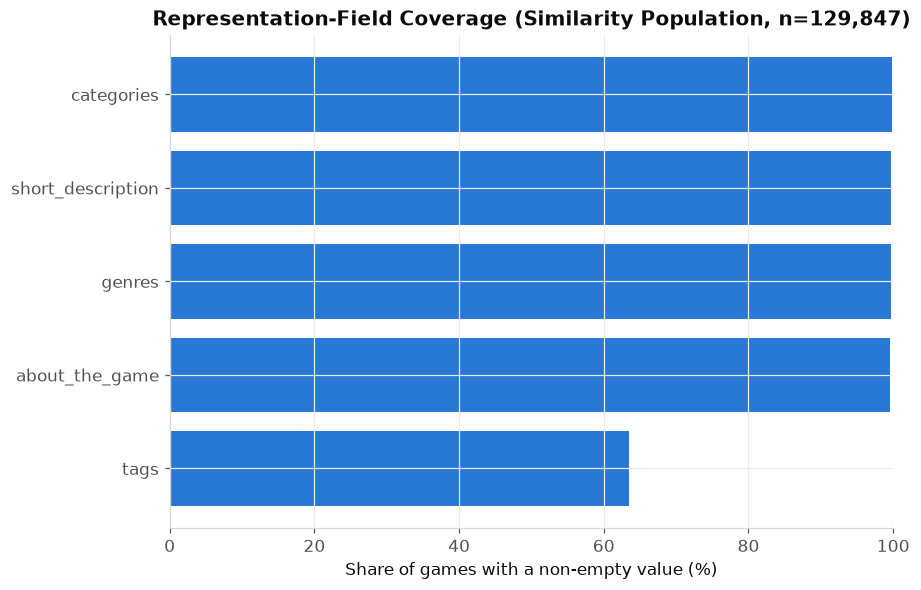

In [25]:
BLUE2, ORANGE2, AQUA2, VIOLET2 = BLUE, ORANGE, AQUA, VIOLET

fig, ax = plt.subplots(figsize=(8.5, 5.5))
fields = ['genres', 'categories', 'tags', 'short_description', 'about_the_game']
coverages = [
    (similarity_frame['genre_list'].apply(len) > 0).mean(),
    (similarity_frame['category_list'].apply(len) > 0).mean(),
    (similarity_frame['tag_list'].apply(len) > 0).mean(),
    (similarity_frame['short_description_clean'].str.len() > 0).mean(),
    (similarity_frame['about_the_game_clean'].str.len() > 0).mean(),
]
order = np.argsort(coverages)
ax.barh(np.array(fields)[order], np.array(coverages)[order] * 100, color=BLUE)
ax.set_title('Representation-Field Coverage (Similarity Population, n=129,847)')
ax.set_xlabel('Share of games with a non-empty value (%)')
ax.set_xlim(0, 100)
fig.tight_layout()
savefig(fig, 'fig1_representation_field_coverage.png')
plt.show()

saved ../figures/phase5/fig2_tag_genre_long_tail.png


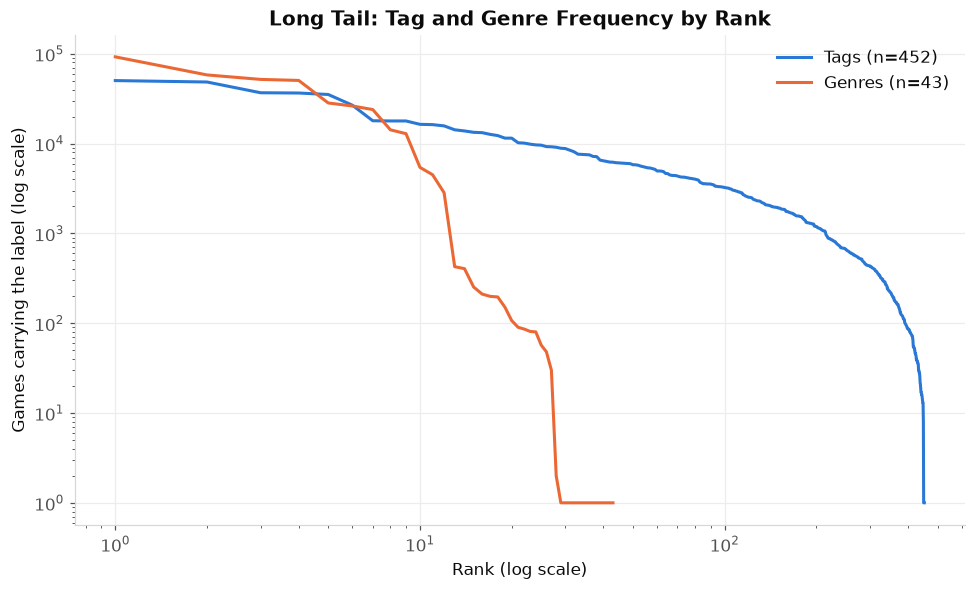

In [26]:
tag_counts_sorted = all_tags.value_counts().sort_values(ascending=False).reset_index(drop=True)
genre_counts_sorted = pd.Series([g for v in similarity_frame['genre_list'] for g in v]).value_counts().sort_values(ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(np.arange(1, len(tag_counts_sorted) + 1), tag_counts_sorted.values, color=BLUE, linewidth=2, label=f'Tags (n={len(tag_counts_sorted)})')
ax.plot(np.arange(1, len(genre_counts_sorted) + 1), genre_counts_sorted.values, color=ORANGE, linewidth=2, label=f'Genres (n={len(genre_counts_sorted)})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Long Tail: Tag and Genre Frequency by Rank')
ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Games carrying the label (log scale)')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
savefig(fig, 'fig2_tag_genre_long_tail.png')
plt.show()

saved ../figures/phase5/fig3_similarity_score_distributions.png


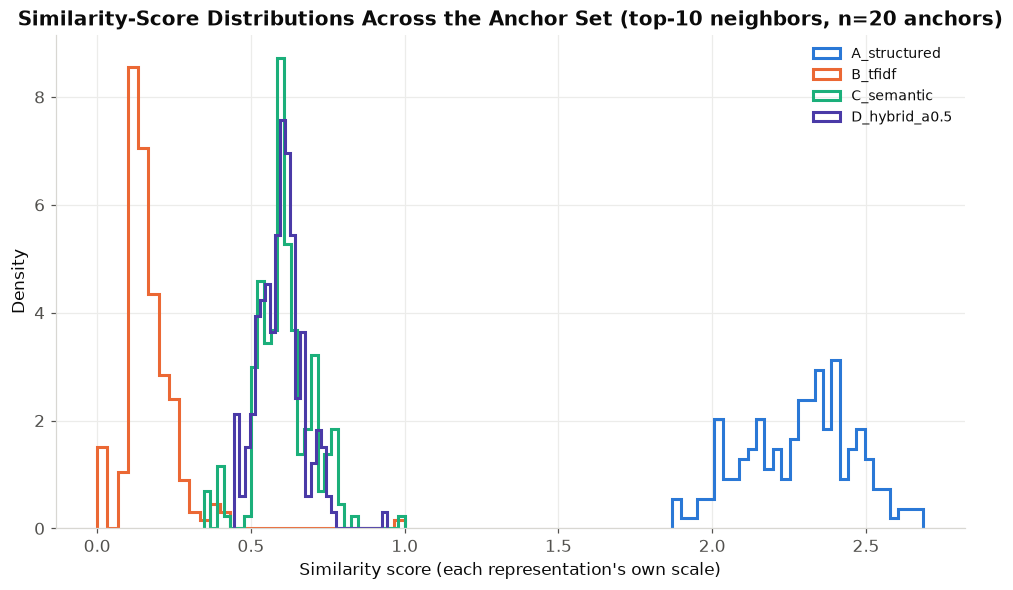

In [27]:
fig, ax = plt.subplots(figsize=(9, 5.5))
rep_colors = {'A_structured': BLUE, 'B_tfidf': ORANGE, 'C_semantic': AQUA, 'D_hybrid_a0.5': VIOLET}
for rep, color in rep_colors.items():
    scores = neighbor_comparison.loc[neighbor_comparison['representation'] == rep, 'similarity_score']
    ax.hist(scores, bins=30, histtype='step', linewidth=2, color=color, label=rep, density=True)
ax.set_title('Similarity-Score Distributions Across the Anchor Set (top-10 neighbors, n=20 anchors)')
ax.set_xlabel('Similarity score (each representation\'s own scale)')
ax.set_ylabel('Density')
ax.legend(loc='upper right', frameon=False, fontsize=9)
fig.tight_layout()
savefig(fig, 'fig3_similarity_score_distributions.png')
plt.show()

saved ../figures/phase5/fig4_structured_vs_semantic_scatter.png


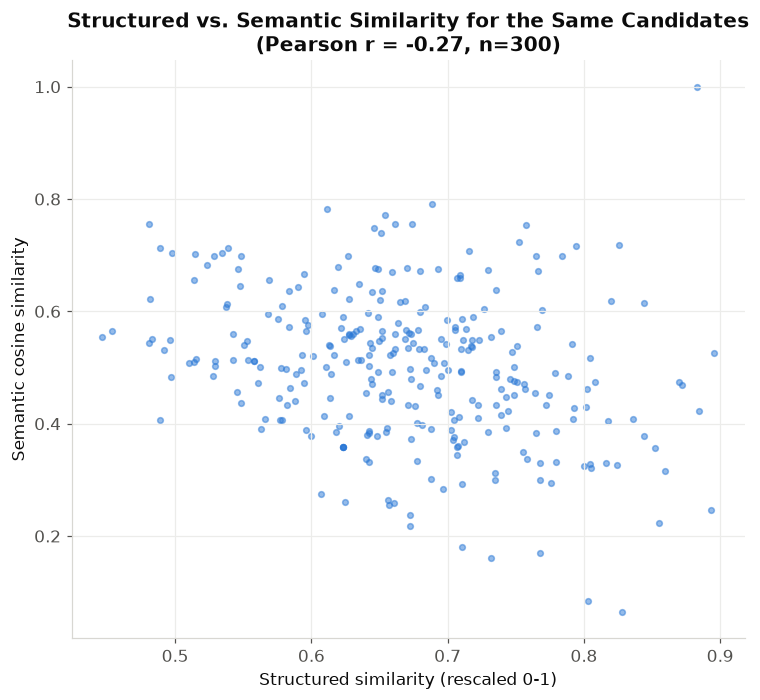

Pearson correlation between structured and semantic scores on the same candidate pool: -0.269


In [28]:
scatter_struct, scatter_sem = [], []
for anchor_name, a_idx in anchor_idx_map.items():
    idx, combined, struct_s, sem_s = hybrid_top_k(a_idx, X_structured, X_embed, alpha=0.5, k=15)
    scatter_struct.extend(struct_s)
    scatter_sem.extend(sem_s)

corr = np.corrcoef(scatter_struct, scatter_sem)[0, 1]
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(scatter_struct, scatter_sem, s=14, alpha=0.5, color=BLUE)
ax.set_title(f'Structured vs. Semantic Similarity for the Same Candidates\n(Pearson r = {corr:.2f}, n={len(scatter_struct)})')
ax.set_xlabel('Structured similarity (rescaled 0-1)')
ax.set_ylabel('Semantic cosine similarity')
fig.tight_layout()
savefig(fig, 'fig4_structured_vs_semantic_scatter.png')
plt.show()
print(f"Pearson correlation between structured and semantic scores on the same candidate pool: {corr:.3f}")

saved ../figures/phase5/fig5_coherence_by_representation.png


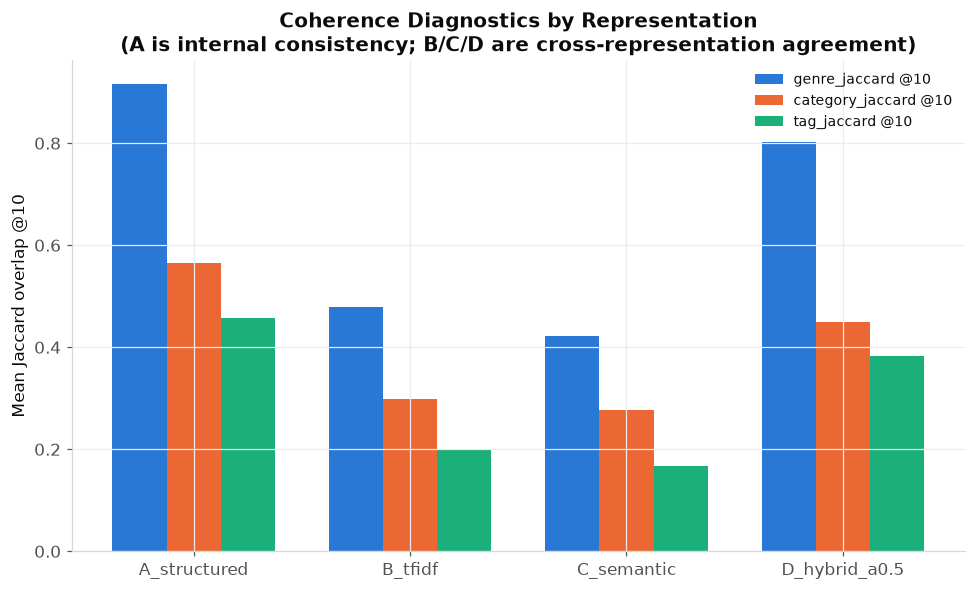

In [29]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(coherence_table))
width = 0.25
metrics = ['mean_genre_jaccard@10', 'mean_category_jaccard@10', 'mean_tag_jaccard@10']
for i, (metric, color) in enumerate(zip(metrics, [BLUE, ORANGE, AQUA])):
    ax.bar(x + (i - 1) * width, coherence_table[metric], width, color=color, label=metric.replace('mean_', '').replace('@10', ' @10'))
ax.set_xticks(x)
ax.set_xticklabels(coherence_table['representation'])
ax.set_title('Coherence Diagnostics by Representation\n(A is internal consistency; B/C/D are cross-representation agreement)')
ax.set_ylabel('Mean Jaccard overlap @10')
ax.legend(loc='upper right', frameon=False, fontsize=9)
fig.tight_layout()
savefig(fig, 'fig5_coherence_by_representation.png')
plt.show()

saved ../figures/phase5/fig6_alpha_sensitivity.png


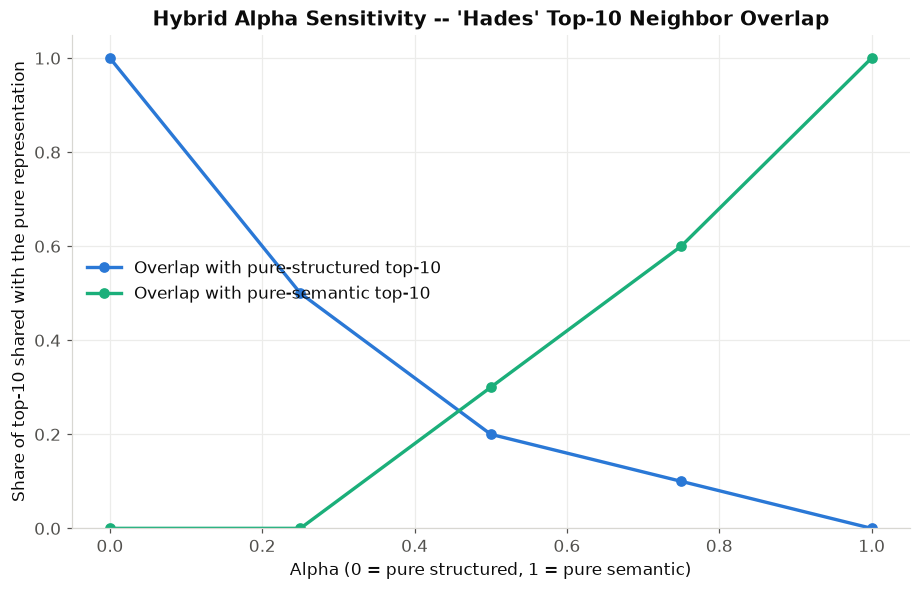

In [30]:
alpha_grid = [0.00, 0.25, 0.50, 0.75, 1.00]
probe_idx = name_to_idx['hades']
_, _, struct_only_idx = None, None, top_k_similar(X_structured[probe_idx], X_structured, k=10, exclude_idx=probe_idx)[0]
_, sem_only_idx = None, top_k_similar(X_embed[probe_idx:probe_idx+1], X_embed, k=10, exclude_idx=probe_idx)[0]
struct_only_set, sem_only_set = set(struct_only_idx), set(sem_only_idx)

overlap_struct, overlap_sem = [], []
for alpha in alpha_grid:
    idx, *_ = hybrid_top_k(probe_idx, X_structured, X_embed, alpha=alpha, k=10)
    idx_set = set(idx)
    overlap_struct.append(len(idx_set & struct_only_set) / 10)
    overlap_sem.append(len(idx_set & sem_only_set) / 10)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(alpha_grid, overlap_struct, marker='o', color=BLUE, linewidth=2.2, label='Overlap with pure-structured top-10')
ax.plot(alpha_grid, overlap_sem, marker='o', color=AQUA, linewidth=2.2, label='Overlap with pure-semantic top-10')
ax.set_title("Hybrid Alpha Sensitivity -- 'Hades' Top-10 Neighbor Overlap")
ax.set_xlabel('Alpha (0 = pure structured, 1 = pure semantic)')
ax.set_ylabel('Share of top-10 shared with the pure representation')
ax.legend(loc='center left', frameon=False)
ax.set_ylim(0, 1.05)
fig.tight_layout()
savefig(fig, 'fig6_alpha_sensitivity.png')
plt.show()

saved ../figures/phase5/fig7_popularity_bias.png


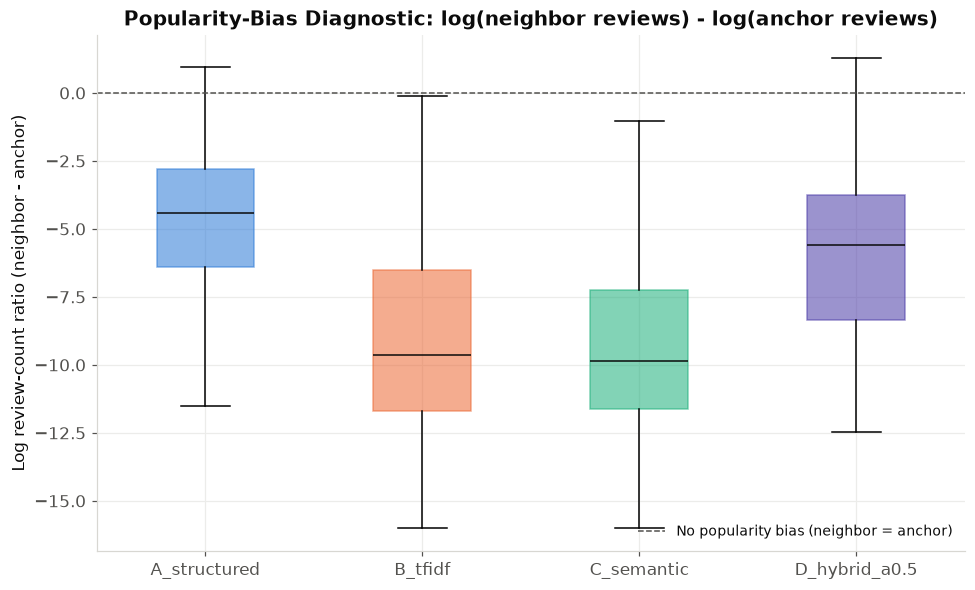

In [31]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_data, labels = [], []
for rep in ['A_structured', 'B_tfidf', 'C_semantic', 'D_hybrid_a0.5']:
    rows = neighbor_comparison[neighbor_comparison['representation'] == rep]
    ratio = np.log1p(rows['neighbor_app_id'].map(review_lookup)) - np.log1p(rows['anchor_app_id'].map(review_lookup))
    plot_data.append(ratio.dropna().values)
    labels.append(rep)
bp = ax.boxplot(plot_data, tick_labels=labels, showfliers=False, patch_artist=True, medianprops=dict(color=TEXT_PRIMARY))
for patch, color in zip(bp['boxes'], [BLUE, ORANGE, AQUA, VIOLET]):
    patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor(color)
ax.axhline(0, color=TEXT_SECONDARY, linewidth=1, linestyle='--', label='No popularity bias (neighbor = anchor)')
ax.set_title('Popularity-Bias Diagnostic: log(neighbor reviews) - log(anchor reviews)')
ax.set_ylabel('Log review-count ratio (neighbor - anchor)')
ax.legend(loc='lower right', frameon=False, fontsize=9)
fig.tight_layout()
savefig(fig, 'fig7_popularity_bias.png')
plt.show()

**Two figures surface findings not fully visible in the tables above:**

- **Fig. 4 (structured vs. semantic scatter): Pearson r = -0.27** between structured and semantic similarity
  scores for the same candidate pool — not just uncorrelated, **weakly negatively correlated**. The two
  representations are genuinely capturing different (even mildly opposing) notions of "similar," which is
  the strongest quantitative support in this notebook for why a hybrid is worth having at all: if the two
  signals agreed, blending them would add complexity without adding information.
- **Fig. 7 (popularity bias):** confirms Task 16's finding visually and shows it's not evenly spread —
  `B_tfidf` and `C_semantic` show the most extreme skew toward less-visible neighbors (median around -10 in
  log-review-ratio), while `A_structured` and `D_hybrid` are less extreme (around -4.5 to -5.6). Text-based
  representations drift furthest toward the long tail; structured metadata (present for nearly all games
  regardless of popularity) drifts least.

---
# 21. Case Studies

Five anchors selected *after* the broad evaluation above, chosen to illustrate different behaviors —
including one clear failure. Not a highlight reel: this section reports what actually happened.

## Case 1 — Hades: structured recovers a "spiritual catalog," semantic finds theme without gameplay

Already detailed in Tasks 9/14. Structured metadata (`alpha=0.0`) surfaces `Hades II`, `Bastion`, `Transistor`,
`Pyre` — Supergiant Games' entire other catalog — **without developer identity ever being a feature**; genre/
category/tag overlap alone was enough. Pure semantic embeddings (`alpha=1.0`) surface `Bloody Heaven 2`,
`Black Myth: Heaven`, `Dungeon Avenger` — titles sharing underworld/heaven mythological vocabulary with
nothing to suggest they share Hades' roguelite combat structure. **What improved:** the hybrid at `alpha=0.5`
(after the score-scale fix) genuinely blends both signals rather than being dominated by one. **What remained
imperfect:** neither pure representation, nor the hybrid, can confirm actual gameplay similarity — only
metadata- and text-level proxies for it.

## Case 2 — Disco Elysium: a clear semantic-embedding failure

**Failure case, not softened.** `Disco Elysium - The Final Cut`'s semantic neighbors are `Angels That Kill -
The Final Cut`, `Deal of the Dead Final Cut`, `The Last Oricru - Final Cut`, `The Incredible Adventures of Van
Helsing: Final Cut` — four unrelated games whose only commonality with Disco Elysium is also being labeled
"Final Cut." **Root cause, confirmed by inspecting the source text**: Disco Elysium's own `short_description`
begins *"Disco Elysium - The Final Cut is a groundbreaking role playing game..."* — the edition label is
embedded directly in the description text the embedding model reads, and MiniLM evidently weights that
repeated, distinctive phrase heavily enough to dominate the resulting vector. **Structured metadata does much
better here**: `ATOM RPG: Post-apocalyptic indie game`, `The Legend of Heroes: Trails of Cold Steel`, `Pillars
of Eternity II: Deadfire` — genuinely comparable narrative-heavy CRPGs. TF-IDF's neighbors (`AIPet`,
`FreedroidRPG`) are not obviously coherent either. **Nothing improved this case within this notebook** — it is
reported as an open failure mode: text-based representations can be misled by incidental, distinctive
substrings (edition/version labels) that carry no thematic meaning.

## Case 3 — DARK SOULS III: franchise dominance and the value of suppression

Already detailed in Task 15. Default retrieval surfaces two same-franchise Dark Souls entries in the top-4;
`suppress_franchise=True` cleanly removes them and reveals `Monster Hunter: World`, `ELDEN RING`, `Dynasty
Warriors 9` as the closest cross-franchise matches. **What improved:** a materially more useful "discovery"
list for someone who already owns the franchise. **What remained imperfect:** the underlying franchise
heuristic is a simple shared-first-word title match (`src/similarity_utils.py::is_likely_same_franchise`) —
it would miss a franchise using inconsistent naming and could over-trigger on an unrelated game that happens
to share a common first word; it is explicitly documented as a lightweight heuristic, not entity resolution.

## Case 4 — Stardew Valley: the success case, where representations largely agree

Across all three base representations, Stardew Valley's neighbors converge on genuine farming/life-sim titles
— TF-IDF: `Caravan Village: Farming Life`, `STORY OF SEASONS: A Wonderful Life`, `Coral Island`; semantic:
`Garden Paws`, `STORY OF SEASONS: A Wonderful Life`, `Sky Harvest`; structured (equal weights): `One Lonely
Outpost`, `My Time at Sandrock`. **What improved:** nothing needed fixing — this is the case that validates
the overall approach when a game has rich, distinctive tags/description and a well-defined genre niche.
**What remained imperfect:** even here, no representation guarantees these games play *identically* to
Stardew Valley — only that they describe themselves similarly, which is this project's honest ceiling
throughout (see "What 'Similar' Means," below).

## Case 5 — Papers, Please: why the Task 5 tag-weighting decision mattered

Already detailed in Task 5. Down-weighting tags pulled in the *Deponia* fantasy-comedy adventure series on
genre/category overlap alone, missing Papers, Please's actual political-simulation theme entirely; equal
weighting recovered `Wait! Life is beautiful!` and `Don't Escape: 4 Days to Survive` instead — genuinely
closer in theme. **What improved:** the Task 5 weighting decision, validated concretely by this anchor.
**What remained imperfect:** TF-IDF's own neighbor list for Papers, Please was not independently inspected in
depth here — a reminder that this notebook's evaluation, while broader than a single anchor, is still a
sample of 20 games, not exhaustive coverage of every representation's behavior across the full catalog.

---
# 22. Final Representation Decision

**Decision: D. Hybrid (alpha=0.5, after the score-scale fix) as the recommended default — not because
hybrid automatically wins, but because it's the choice that best balances demonstrated, real failure modes
without introducing a new one of its own.** This is closer to D-with-E's-caveat than a clean D: every pure
representation retains clear, evidenced comparative advantages, and `find_similar_games` keeps all four
selectable rather than hiding the other three behind the hybrid default.

**Why the hybrid, specifically:**
- It is the only representation whose two inputs (structured, semantic) were shown to be **weakly negatively
  correlated** (fig. 4, r=-0.27) on the same candidate pool — genuine complementarity, not redundant signal
  being averaged together for no reason.
- Its cross-representation coherence (fig. 5: genre/category/tag Jaccard 0.802/0.449/0.383) sits meaningfully
  **between** structured's (0.916/0.565/0.457) and semantic's (0.422/0.277/0.167) — direct numerical
  confirmation that, after the score-scale fix, it is a genuine blend rather than being dominated by one
  input (an easy way for a "hybrid" to be hybrid in name only, which the pre-fix version actually was).
- Its popularity-bias skew (fig. 7) is the second-mildest of the four, milder than either B_tfidf or
  C_semantic alone.

**Why NOT to treat this as "hybrid always wins," honestly stated:**
- **Structured alone** uniquely recovered Supergiant Games' full catalog for Hades *without ever using
  developer identity as a feature* — a genuinely striking result the hybrid partially dilutes at higher alpha.
- **TF-IDF alone** is the natural fallback specifically *because* of semantic's demonstrated failure mode
  (Case 2): when an edition/version string embedded in the description text derails the embedding, exact
  lexical matching doesn't share that particular vulnerability (though it has its own — franchise-token
  dominance, Task 14).
- **Semantic alone** is the only representation that goes beyond lexical/label overlap to true thematic
  similarity, when that's specifically what a user wants (e.g. "give me the mood/theme, not the genre tag").

**Practical recommendation:** ship the hybrid as `find_similar_games`'s default (already implemented this
way), but keep `representation='structured'|'tfidf'|'semantic'` fully supported and documented as legitimate
choices for different discovery intents, not deprecated fallbacks.

---
# What "Similar" Means in This Project

A pair of games is called "similar" here if they **describe themselves alike** — shared genre/category/tag
labels, shared or thematically-related description text, or both, depending on the chosen representation.
This is a claim about **content description**, not about:

- how similar the games actually *play* (no gameplay telemetry, mechanics data, or player session data exists
  in this dataset to check against);
- whether players who liked one would like the other (no interaction/preference data — see the framing note
  at the top of this notebook);
- how commercially comparable they are (popularity was deliberately excluded from every representation, and
  Task 16 shows retrieval is if anything biased *away* from popular titles, not toward them);
- any claim about quality, critical reception, or player satisfaction.

**What the system does NOT claim:** personalized recommendation, collaborative filtering, recommendation
accuracy/precision/recall/NDCG (no ground truth exists to compute these honestly), or that "similar" implies
"a player who enjoyed the anchor will enjoy the neighbor."

---
# Limitations

1. **No independent ground truth exists for any quantitative claim in this notebook** — every coherence
   number is either internal consistency (representation A) or cross-representation agreement (B, C, D), not
   validated accuracy.
2. **Multilingual content is not specially handled.** Descriptions and even some genre/category labels appear
   in multiple languages; `all-MiniLM-L6-v2` is primarily English-optimized, so non-English descriptions
   likely embed less reliably than English ones — not separately measured in this notebook.
3. **The franchise-suppression heuristic is intentionally simple** (shared first significant title word) and
   will both under- and over-trigger on real cases outside the ones checked here.
4. **The anchor set is 20 games** — broader than a single cherry-picked example, but still a sample; case
   studies (5 of the 20) are illustrative, not exhaustive, of each representation's behavior.
5. **Semantic embeddings can be misled by incidental text** (Case 2: an edition-label string embedded in
   description text), a failure mode not fully solvable within this notebook's scope.
6. **Popularity bias exists and was measured, not corrected** — retrieval systematically favors less-visible
   neighbors over more-visible ones, most strongly for text-based representations; this is reported as a
   representation characteristic, not engineered out.
7. **This is a snapshot-in-time system**: like every other phase of this project, it reflects the 2026-08-28
   catalog snapshot and would need to be regenerated (deterministically, from `steam_games.csv`) to reflect a
   later catalog state.

---
# Recommended Next Phase

The clearest gap this phase surfaced is that **no representation here can distinguish description quality
from gameplay similarity** — Case 2 (Disco Elysium) shows text can actively mislead when a distinctive but
non-thematic string dominates. A natural next step is **not** more representation engineering, but using
Phase 4's and this phase's outputs together: combine cohort-relative visibility (Phase 4) with content
similarity (this phase) to ask a genuinely new question — e.g., "among games structurally similar to X, which
ones substantially over/under-perform their content-similarity peers in visibility," a descriptive analysis
that stays within this project's established non-causal, cohort-aware methodology rather than opening a new,
separate modeling track.